In [ ]:
#MINI BATCH K MEANS PROJECT

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sn

In [3]:
data = pd.read_csv('/content/Health Insurance.csv')
data.head(3)

,age,gender,bmi,children,smoker,region,charges
0,19,female,28,0,yes,southwest,16885
1,18,male,34,1,no,southeast,1726
2,28,male,33,3,no,southeast,4449


In [4]:
data.columns

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       1338 non-null   int64 
 1   gender    1338 non-null   object
 2   bmi       1338 non-null   int64 
 3   children  1338 non-null   int64 
 4   smoker    1338 non-null   object
 5   region    1338 non-null   object
 6   charges   1338 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 73.3+ KB


In [6]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data["gender"]=le.fit_transform(data.gender)      #0 female, 1 male
data["smoker"]=le.fit_transform(data.smoker)      #0 no, 1 yes
data["region"]=le.fit_transform(data.region)
data.head(2)

,age,gender,bmi,children,smoker,region,charges
0,19,0,28,0,1,3,16885
1,18,1,34,1,0,2,1726


In [7]:
data.columns

Index(['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [8]:
x = data[['age', 'gender', 'bmi', 'children', 'smoker', 'region', 'charges']]
y = data[['charges']]

In [9]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc1=sc.fit_transform(x)

In [10]:
sc1

array([[-1.43876426, -1.0105187 , -0.43878458, ...,  1.97058663,
         1.34390459,  0.29859066],
       [-1.50996545,  0.98959079,  0.54599669, ..., -0.5074631 ,
         0.43849455, -0.95365144],
       [-0.79795355,  0.98959079,  0.38186648, ..., -0.5074631 ,
         0.43849455, -0.72871212],
       ...,
       [-1.50996545, -1.0105187 ,  1.03838732, ..., -0.5074631 ,
         0.43849455, -0.96158173],
       [-1.29636188, -1.0105187 , -0.767045  , ..., -0.5074631 ,
         1.34390459, -0.93035622],
       [ 1.55168573, -1.0105187 , -0.27465437, ...,  1.97058663,
        -0.46691549,  1.31102414]])

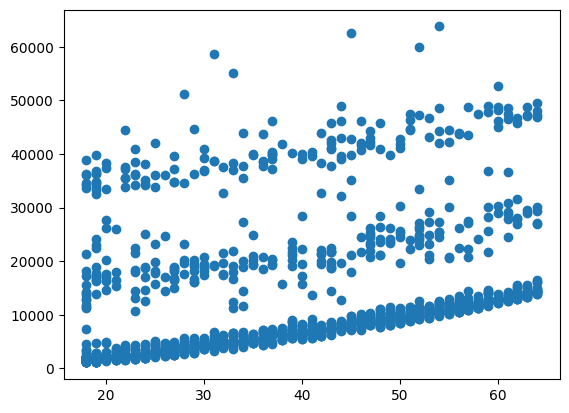

In [11]:
plt.scatter(data.age,data.charges)

In [12]:
from sklearn.cluster import MiniBatchKMeans

In [13]:
mbk = MiniBatchKMeans(init ='k-means++', n_clusters = 4,
                      batch_size = 40, n_init = 10,
                      max_no_improvement = 10, verbose = 0)

In [14]:
fit=mbk.fit(data[["age","charges"]])

In [15]:
predict=fit.fit_predict(data[["age","charges"]])
predict

array([3, 1, 1, ..., 1, 1, 0], dtype=int32)

In [16]:
unique=set((fit.labels_))
unique

{np.int32(0), np.int32(1), np.int32(2), np.int32(3)}

In [17]:
data["clusters"]=predict
data.head(5)

,age,gender,bmi,children,smoker,region,charges,clusters
0,19,0,28,0,1,3,16885,3
1,18,1,34,1,0,2,1726,1
2,28,1,33,3,0,2,4449,1
3,33,1,23,0,0,1,21984,0
4,32,1,29,0,0,1,3867,1


In [18]:
data1=data[data.clusters==0]
data2=data[data.clusters==1]
data3=data[data.clusters==2]
data4=data[data.clusters==3]

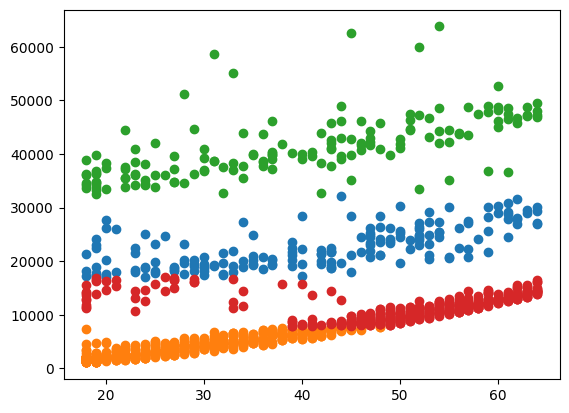

In [19]:
plt.scatter(data1.age,data1.charges)
plt.scatter(data2.age,data2.charges)
plt.scatter(data3.age,data3.charges)
plt.scatter(data4.age,data4.charges)

In [20]:
fit.cluster_centers_

array([[4.31666667e+01, 2.27677000e+04],
       [3.05410628e+01, 4.47463768e+03],
       [3.90508475e+01, 4.17484746e+04],
       [5.01233766e+01, 1.13602468e+04]])

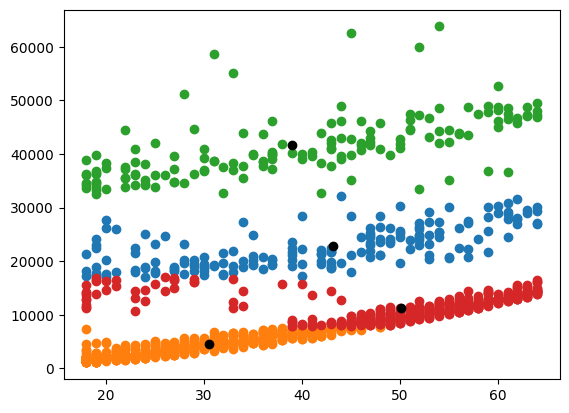

In [21]:
plt.scatter(data1.age,data1.charges)
plt.scatter(data2.age,data2.charges)
plt.scatter(data3.age,data3.charges)
plt.scatter(data4.age,data4.charges)

plt.scatter(fit.cluster_centers_[:,0],fit.cluster_centers_[:,1],color="Black")

In [22]:
sse=[]
range=(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15.16,17,18,19,20)

In [23]:
for i in range:
    MiniBatchKMeans(init ='k-means++', n_clusters = i, batch_size = 40, n_init = 10, max_no_improvement = 10, verbose = 0)
    mbk.fit(data[["age","charges"]])
    fit.fit_predict(data[["age","charges"]])
    sse.append(fit.inertia_)

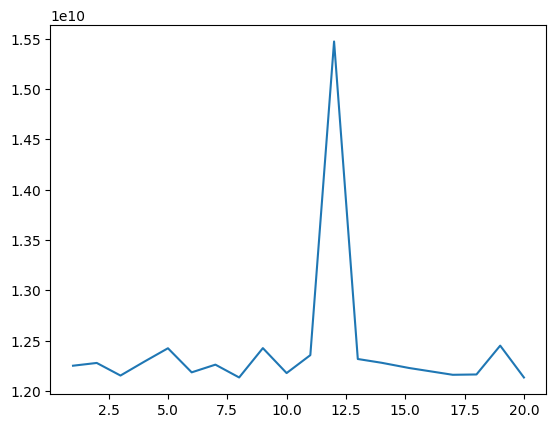

In [24]:
plt.plot(range,sse)